In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

import pickle

import schwingerModel as sim

In [2]:
def coshCorrel(nt, Energy, dimt, ti):
    return (np.exp(-(nt+ti)*Energy)+np.exp(((nt+ti)-dimt)*Energy))/(np.exp(-(ti)*Energy)+np.exp(((ti)-dimt)*Energy))

In [3]:
with open('configs/50kSteps_a_2.pkl', 'rb') as f:
    a2 = pickle.load(f)

with open('configs/50kSteps_a_1.5.pkl', 'rb') as f:
    a15 = pickle.load(f)

with open('configs/50kSteps.pkl', 'rb') as f:
    a1 = pickle.load(f)

with open('configs/50kSteps_a_0.5.pkl', 'rb') as f:
    a5 = pickle.load(f)

with open('configs/20kSteps_a_0.33.pkl', 'rb') as f:
    a33 = pickle.load(f)

with open('configs/1kSteps_a_0.25.pkl', 'rb') as f:
    a25 = pickle.load(f)

In [5]:
a33.dimt/3

32.0

In [4]:
bIn = 500
skp = 500

gamma = np.array([[1j,0],[0,-1j]])

correl_a2 =  sim.correlation.correlStats(a2, burnIn=bIn,autocorrSkip=skp,Gamma1=gamma)
correl_a15 =  sim.correlation.correlStats(a15, burnIn=bIn,autocorrSkip=skp,Gamma1=gamma)
correl_a1 =  sim.correlation.correlStats(a1, burnIn=bIn,autocorrSkip=skp,Gamma1=gamma)
correl_a5 =  sim.correlation.correlStats(a5, burnIn=bIn,autocorrSkip=skp,Gamma1=gamma)

# correl_a33 = sim.correlation.correlStats(a33, burnIn=bIn,autocorrSkip=skp,Gamma1=gamma,saveProps=True)
# correl_a25 = sim.correlation.correlStats(a25, burnIn=100,autocorrSkip=900//40,Gamma1=gamma,saveProps=True)

100%|██████████| 99/99 [00:34<00:00,  2.91it/s]


Text(0.5, 1.0, 'Correlation: $L_t = 32a$, $L_x=16a$, $m=0.2$, $\\Gamma=\\sigma_3$')

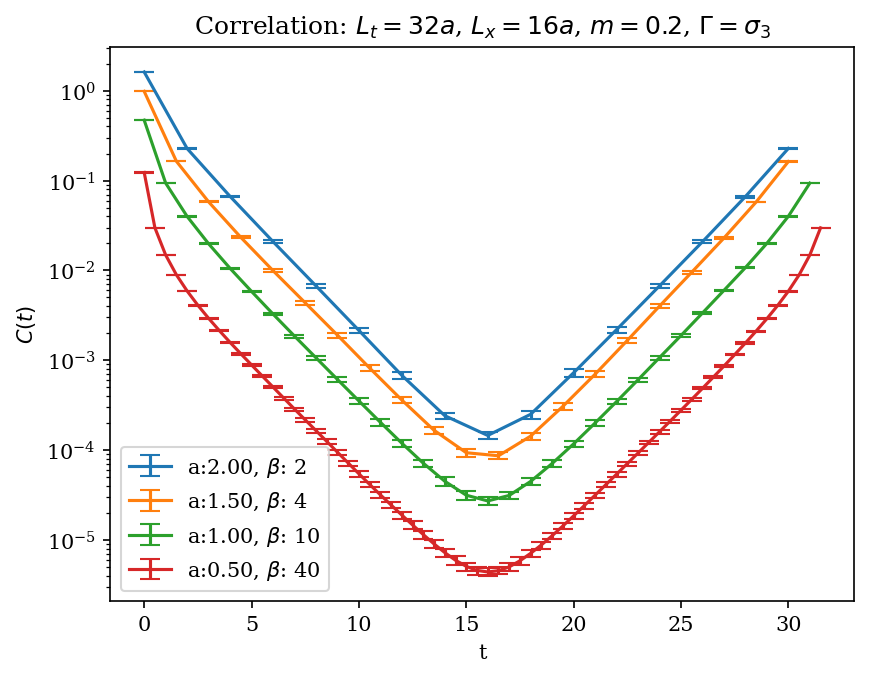

In [ ]:
a2X = np.arange(stop = a1.dimt,step = a2.a)
a15X = np.arange(stop = a1.dimt-1,step = a15.a)
a1X = np.arange(stop = a1.dimt,step = a1.a)
a5X = np.arange(stop = a1.dimt,step = a5.a)
a33X = np.arange(stop = a1.dimt,step = a33.a)
a25X = np.arange(stop = a1.dimt,step = a25.a)

initInd = 1

plt.figure(dpi=150)
plt.errorbar(x=a2X[initInd:], y=correl_a2[0]/(a2.a**0), yerr=correl_a2[1]/(a2.a**0),capsize=5, label=rf"a:{a2.a:.2f}, $\beta$: {a2.beta:.0f}")
plt.errorbar(x=a15X[initInd:], y=correl_a15[0]/(a2.a**0), yerr=correl_a15[1]/(a2.a**0),capsize=5, label=rf"a:{a15.a:.2f}, $\beta$: {a15.beta:.0f}")
plt.errorbar(x=a1X[initInd:], y=correl_a1[0]/(a1.a**0), yerr=correl_a1[1]/(a1.a**0),capsize=5, label=rf"a:{a1.a:.2f}, $\beta$: {a1.beta:.0f}")
plt.errorbar(x=a5X[initInd:], y=correl_a5[0]/(a5.a**0), yerr=correl_a5[1]/(a5.a**0),capsize=5, label=rf"a:{a5.a:.2f}, $\beta$: {a5.beta:.0f}")
# plt.errorbar(x=a33X[1:], y=correl_a33[0]/(a33.a**0), yerr=correl_a33[1]/(a33.a**0),capsize=5, label=rf"a:{a33.a:.2f}, $\beta$: {a33.beta:.0f}")
# plt.errorbar(x=a25X[1:], y=correl_a25[0]/(a25.a**0), yerr=correl_a25[1]/(a25.a**0),capsize=5, label=rf"a:{a25.a:.2f}, $\beta$: {a25.beta:.0f}")

plt.semilogy()
plt.legend()
plt.xlabel("t")
plt.ylabel(r"$C(t)$")
plt.title(rf"Correlation: $L_t = 32a$, $L_x=16a$, $m={a2.fMass}$, $\Gamma=\sigma_3$")

In [5]:
bIn = 500
skp = 500
ti=1

gamma = np.array([[1j,0],[0,-1j]])

correl_a2 =  sim.correlation.GEVPStats(a2, burnIn=bIn,autocorrSkip=skp//12,Gamma=gamma,smearNs=[0,2],kappas=[0,1.2],ti=ti,momk=0)
correl_a15 = sim.correlation.GEVPStats(a15, burnIn=bIn,autocorrSkip=skp//12,Gamma=gamma,smearNs=[0,2],kappas=[0,1.2],ti=ti,momk=0)
correl_a1 =  sim.correlation.GEVPStats(a1, burnIn=bIn,autocorrSkip=skp//12,Gamma=gamma,smearNs=[0,4],kappas=[0,1.2],ti=ti,momk=0)
correl_a5 =  sim.correlation.GEVPStats(a5, burnIn=bIn,autocorrSkip=skp//2,Gamma=gamma,smearNs=[0,8],kappas=[0,1.2],ti=ti,momk=0)

100%|██████████| 198/198 [00:21<00:00,  9.39it/s]


In [5]:
correl_a33 = sim.correlation.GEVPStats(a33, burnIn=bIn,autocorrSkip=skp//2,Gamma=gamma,smearNs=[0,4,25],kappas=[0,1.2,.5],ti=ti,momk=0,n_jobs=8)

100%|██████████| 78/78 [00:30<00:00,  2.54it/s]


In [ ]:
correl_a25 = sim.correlation.GEVPStats(a25, burnIn=100,autocorrSkip=900//100,Gamma=gamma,smearNs=[0,5,30],kappas=[0,.5,.5],ti=ti,momk=0,n_jobs=8)

100%|██████████| 100/100 [01:31<00:00,  1.09it/s]


In [42]:
mass_a2 = sim.correlation.gevpMassExtract(correl_a2,fitT=[3,14])
mass_a15 = sim.correlation.gevpMassExtract(correl_a15,fitT=[3,20])
mass_a1 = sim.correlation.gevpMassExtract(correl_a1,fitT=[2,30])
mass_a5 = sim.correlation.gevpMassExtract(correl_a5,fitT=[20,45])
mass_a33 = sim.correlation.gevpMassExtract(correl_a33,fitT=[30,70])
mass_a25 = sim.correlation.gevpMassExtract(correl_a25,fitT=[50,70])

Text(0.5, 1.0, 'Pseudoscalar Mass vs. spacing')

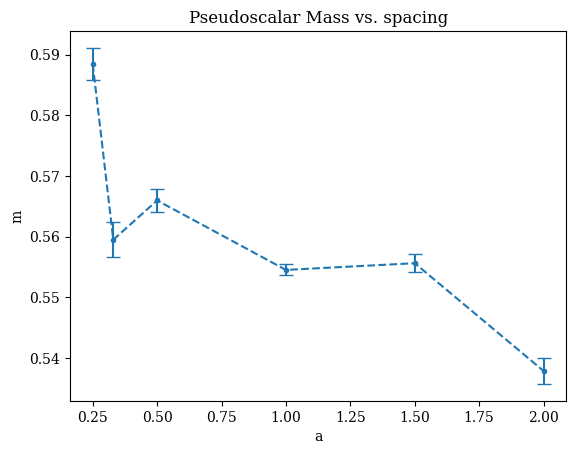

In [45]:
plt.errorbar(x=[.25,.33,.5,1,1.5,2],y=[mass_a25[0]/a25.a,mass_a33[0]/a33.a,mass_a5[0]/a5.a,mass_a1[0]/a1.a,mass_a15[0]/a15.a,mass_a2[0]/a2.a]
                                ,yerr=[mass_a25[1]/a25.a,mass_a33[1]/a33.a,mass_a5[1]/a5.a,mass_a1[1]/a1.a,mass_a15[1]/a15.a,mass_a2[1]/a2.a]
                                ,marker=".",ls="--",capsize=5)

plt.xlabel("a")
plt.ylabel("m")
plt.title("Pseudoscalar Mass vs. spacing")

In [1]:
ti = 1

configs = [
    (a2,  correl_a2,  mass_a2,  15),
    (a15, correl_a15, mass_a15, 20),
    (a1,  correl_a1,  mass_a1,  31),
    (a5,  correl_a5,  mass_a5,  63),
    (a33,  correl_a33,  mass_a33,  96),
    (a25,  correl_a25,  mass_a25,  127),
]

fig, axes = plt.subplots(3, 2, figsize=(10, 8), dpi=150)

for ax, (model, correl, mass, fitT) in zip(axes.flat, configs):
    dimt = len(correl[0]) + ti

    def coshCorrel(nt, E, dimt=dimt, ti=ti):
        return (np.exp(-(nt + ti) * E) + np.exp(((nt + ti) - dimt) * E)) / \
               (np.exp(-ti * E) + np.exp((ti - dimt) * E))

    nt_data = np.arange(len(correl[0]))
    nt_fine = np.linspace(0, fitT - 1, 300)

    ax.errorbar(nt_data + ti, correl[0][:,0], yerr=correl[1][:,:,0], fmt='.', capsize=4,
                markersize=4, label='GEVP')
    ax.plot(nt_fine + ti, coshCorrel(nt_fine, mass[0]),
            label=rf'$m = {mass[0]/model.a:.4f} \pm {mass[1]/model.a:.4f}$')
    ax.set_yscale('log')
    ax.set_xlabel(r'$n_t$')
    ax.set_ylabel('GEVP correlator')
    ax.set_title(rf'$a = {model.a:.2f}$, $\beta = {model.beta:.0f}$')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle(rf'GEVP correlators with cosh fit, $m_0 = {a1.fMass}$', y=1.02)
plt.show()

NameError: name 'a2' is not defined